In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cleaned_ECEC_labour_2022 dataset.csv")

excluded_cols = ['prov', 'fem_empl_rate', 'urban_type']
df = df.drop(columns=excluded_cols)

In [3]:
corr_matrix = df.corr()

# avoid duplicate pairs and self-correlation
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.89

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)

high_corr_pairs = (
    high_corr_pairs[high_corr_pairs['corr'].abs() >= threshold]
    .sort_values(by='corr', key=np.abs, ascending=False)
)

In [4]:
print("Highly correlated pairs")
print(high_corr_pairs.to_string(index=False, float_format=lambda x: f"{x: .3f}"))

Highly correlated pairs
                              var1                         var2   corr
other_percapita_public_expenditure other_per_capita_expenditure  0.995
                         empl_rate                   inact_rate -0.989
                net_migration_rate       adj_net_migration_rate  0.985
                         part_rate                   inact_rate -0.978
                         part_rate                    empl_rate  0.973
                      fem_edu_rate                male_edu_rate  0.952
                       unempl_rate                    empl_rate -0.918
                         empl_rate                   young_neet -0.900


In [5]:
var_counts = (
    pd.concat([high_corr_pairs["var1"], high_corr_pairs["var2"]])
      .value_counts()
)

var_presence_list = list(var_counts.items())

for var, count in var_presence_list:
    print(f"({var}, {count})")

(empl_rate, 4)
(inact_rate, 2)
(part_rate, 2)
(net_migration_rate, 1)
(other_percapita_public_expenditure, 1)
(unempl_rate, 1)
(fem_edu_rate, 1)
(other_per_capita_expenditure, 1)
(adj_net_migration_rate, 1)
(male_edu_rate, 1)
(young_neet, 1)


In [6]:
# we will talk about which one actually to drop

var_to_drop = ['empl_rate', 'inact_rate', 'male_edu_rate', 'other_per_capita_expenditure', 'adj_net_migration_rate']

df_reduced = df.drop(columns=var_to_drop)

In [7]:
selected_covariates = list(df_reduced.columns)

df_full = pd.read_csv("../data/cleaned_ECEC_labour_2022 dataset.csv")
target_col = "fem_empl_rate"

df_model = df_full[[target_col] + selected_covariates].dropna()

print("Selected covariates used in the model:")
print(selected_covariates)


X = df_model[selected_covariates].to_numpy()
y = df_model[target_col].to_numpy()


# standardize predictors and the target
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

y_mean = y.mean()
y_std = y.std()
y_scaled = (y - y_mean) / y_std

n_obs, n_feat = X_scaled.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")


Selected covariates used in the model:
['population', 'unempl_rate', 'part_rate', 'empl_growth', 'fem_edu_rate', 'service_empl_rate', 'GDP', 'n_large_comp', 'n_self_empl', 'young_neet', 'fem_house_rate', 'foreign_rate', 'n_members_family', 'elderly_in_care', 'house_price', 'fertility_rate', 'first_birth_maternal_age', 'avg_children_per_woman', 'dependency_rate', 'ageing_index', 'net_migration_rate', 'area_km2', 'public_transport_supply', 'internet_coverage_rate', 'graduate_mobility_rate', 'green_m2_capita', 'eco_urban_index', 'per_capita_public_expenditure', 'ecec_participation', 'coverage', 'per_capita_user_contribution', 'advanced_business_empl', 'lifelong_learn', 'startup_ratio', 'GERD_total_intramural', 'public_coverage', 'private_coverage', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'fem_maj_empl_rate']

Number of observations: 107, number of predictors: 40


In [8]:
with pm.Model() as bl_model:
    X_data = pm.Data("X_data", X_scaled)
    y_data = pm.Data("y_data", y_scaled)

    lambda_ = pm.Gamma("lambda", alpha=0.1, beta=0.1)
    sigma = pm.HalfNormal("sigma", sigma=1.0)


    beta = pm.Laplace(
        "beta",
        mu=0.0,
        b=sigma / lambda_,
        shape=n_feat
    )


    mu = pm.math.dot(X_data, beta)

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)


    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda, sigma, beta]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 50 seconds.


In [12]:
summary_beta = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta.index = selected_covariates

summary_beta["contains_zero"] = (
    (summary_beta["hdi_2.5%"] <= 0) &
    (summary_beta["hdi_97.5%"] >= 0)
)

summary_beta = summary_beta.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])

                                     mean  hdi_2.5%  hdi_97.5%  contains_zero
fem_house_rate                     -0.455    -0.553     -0.355          False
part_rate                           0.331     0.226      0.451          False
ageing_index                        0.181     0.075      0.277          False
unempl_rate                        -0.172    -0.224     -0.120          False
fertility_rate                     -0.103    -0.198     -0.006          False
avg_children_per_woman             -0.057    -0.117      0.003           True
net_migration_rate                 -0.055    -0.123      0.009           True
n_members_family                   -0.054    -0.109      0.001           True
fem_edu_rate                       -0.048    -0.090     -0.006          False
graduate_mobility_rate              0.035    -0.030      0.106           True
per_capita_user_contribution        0.034    -0.013      0.084           True
private_coverage                    0.026    -0.041      0.094  

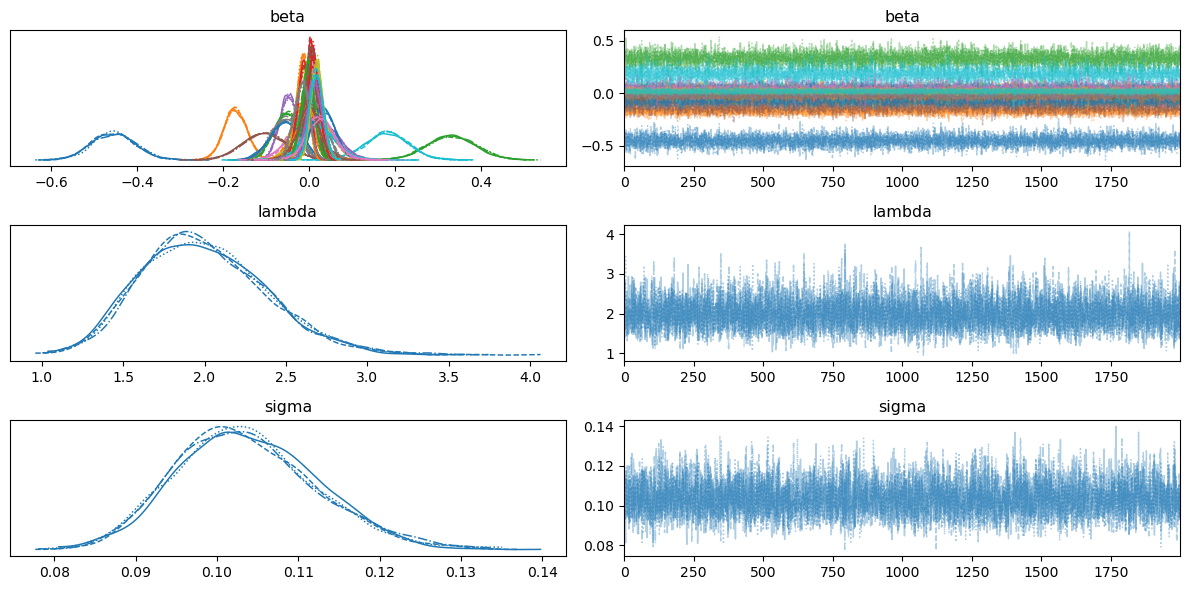

In [13]:
# az.rcParams["plot.max_subplots"] = 100   
# az.plot_trace(trace, compact=False)

az.plot_trace(trace)
plt.tight_layout()

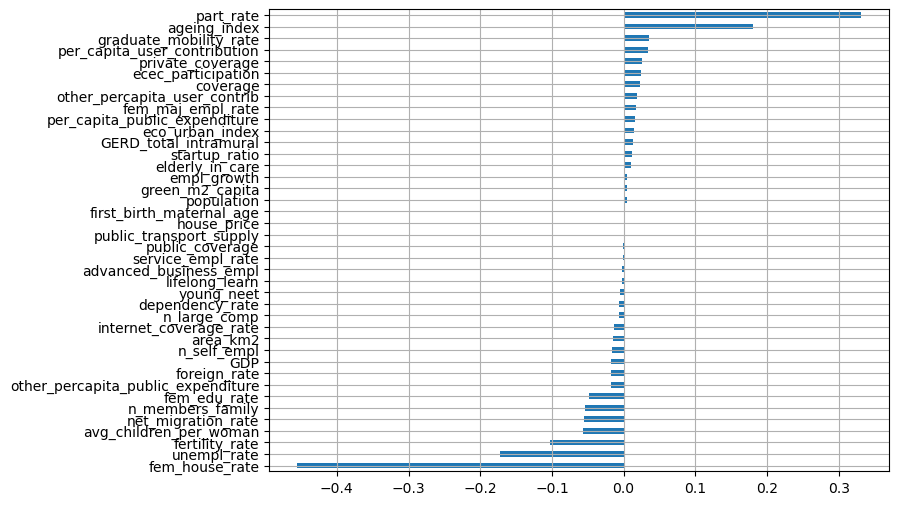

In [15]:
plt.figure(figsize=(8,6))
summary_beta["mean"].sort_values().plot(kind='barh')
plt.grid(True)
plt.show()